In [1]:
# Exploration mesures de pesticides

In [2]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = (
    pl.read_excel(
        "../../data/raw/pesticides_2002_2023_v07_2025.xlsx",
        sheet_name="pesticides_2002_2023_v-07-2025",
    )
    .with_columns([
        pl.col("Code INSEE").cast(pl.Utf8).str.zfill(5),
        pl.col("Debut prelevement").cast(pl.Datetime).dt.date(),
        pl.col("Fin prelevement").cast(pl.Datetime).dt.date(),
    ])
)
df.shape

(994257, 17)

In [4]:
df.describe()

statistic,AASQA,Commune,Code INSEE,xlamb93,ylamb93,Debut prelevement,Fin prelevement,Annee,Semaine,Nbre de jours de prelevement,Coupure PM,Debit de prelevement (m3/h),Substance active,Concentration (ng/m3),Detection/quantification,LD (ng/m3),LQ (ng/m3)
str,str,str,str,f64,f64,str,str,f64,f64,f64,str,f64,str,f64,str,f64,f64
"""count""","""994257""","""994257""","""969548""",994257.0,994257.0,"""994257""","""994257""",994257.0,994257.0,994257.0,"""994257""",946620.0,"""994257""",994257.0,"""994257""",716578.0,800358.0
"""null_count""","""0""","""0""","""24709""",0.0,0.0,"""0""","""0""",0.0,0.0,0.0,"""0""",47637.0,"""0""",0.0,"""0""",277679.0,193899.0
"""mean""",null,null,null,585723.324037,6.6132e6,"""2017-01-04 21:45:29.075882""","""2017-01-11 10:57:27.915780""",2016.494243,27.874376,6.550441,null,2.756342,null,0.26567,null,0.073442,0.165722
"""std""",null,null,null,1.1688e6,583001.590285,null,null,5.503934,11.806437,1.841203,null,6.170097,null,25.725408,null,0.253938,0.360877
"""min""","""AIR BREIZH""","""ARLES""","""02239""",-6.469109e6,483648.0,"""2002-04-08""","""2002-04-10""",2002.0,1.0,1.0,"""PM10""",1.0,"""2,4-D""",0.0,"""""",0.0,0.0
"""25%""",null,null,null,486329.0,6.511113e6,"""2014-04-22""","""2014-04-25""",2014.0,19.0,7.0,null,1.0,null,0.0,null,0.02,0.06
"""50%""",null,null,null,622785.0,6.704644e6,"""2018-09-17""","""2018-09-24""",2018.0,27.0,7.0,null,1.0,null,0.0,null,0.04,0.12
"""75%""",null,null,null,783039.0,6.844846e6,"""2021-05-31""","""2021-06-07""",2021.0,37.0,7.0,null,1.0,null,0.0,null,0.05,0.15
"""max""","""QUALITAIR CORSE""","""Ã‰couflant""","""97617""",1.0257384e7,7.092427e6,"""2023-12-26""","""2024-01-02""",2023.0,53.0,68.0,"""TSP""",30.0,"""Zoxamide""",12649.327,"""<LQ""",14.88,15.3


In [5]:
# Codes insee
print("Nombre de communes: ", df["Code INSEE"].n_unique())
print("Liste des communes: ")
df["Code INSEE"].unique().sort()

Nombre de communes:  183
Liste des communes: 


Code INSEE
str
null
"""02239"""
"""02691"""
"""02701"""
"""06029"""
…
"""97224"""
"""97226"""
"""97310"""


Les codes postaux marqués comme null sont les codes postaux de la Corse, à traiter plus tard

In [6]:
# Visualisation des communes avec Code INSEE null
from pyproj import Transformer
import folium

# Extraire les lignes avec code INSEE null et dédupliquer par commune
communes_null = (
    df
    .filter(pl.col("Code INSEE").is_null())
    .select(["Commune", "AASQA", "xlamb93", "ylamb93"])
    .unique()
    .sort("Commune")
)

print(f"{communes_null.shape[0]} stations avec Code INSEE null :")
print(communes_null)

# Conversion Lambert 93 → WGS84
transformer = Transformer.from_crs("EPSG:2154", "EPSG:4326", always_xy=True)
x = communes_null["xlamb93"].cast(pl.Float64).to_numpy()
y = communes_null["ylamb93"].cast(pl.Float64).to_numpy()
lon, lat = transformer.transform(x, y)

# Carte centrée sur le barycentre des points
centre_lat = lat.mean()
centre_lon = lon.mean()

m = folium.Map(location=[centre_lat, centre_lon], zoom_start=7, tiles="CartoDB positron")

for i, row in enumerate(communes_null.iter_rows(named=True)):
    folium.CircleMarker(
        location=[lat[i], lon[i]],
        radius=2,
        color="#e63946",
        fill=True,
        fill_color="#e63946",
        fill_opacity=0.8,
        tooltip=f"{row['Commune']} ({row['AASQA']})",
    ).add_to(m)

m

8 stations avec Code INSEE null :
shape: (8, 4)
┌───────────────────┬─────────────────┬─────────┬─────────┐
│ Commune           ┆ AASQA           ┆ xlamb93 ┆ ylamb93 │
│ ---               ┆ ---             ┆ ---     ┆ ---     │
│ str               ┆ str             ┆ i64     ┆ i64     │
╞═══════════════════╪═════════════════╪═════════╪═════════╡
│ Ajaccio           ┆ QUALITAIR CORSE ┆ 1177998 ┆ 6111721 │
│ Ajaccio           ┆ QUALITAIR CORSE ┆ 1176382 ┆ 6108865 │
│ Ajaccio           ┆ QUALITAIR CORSE ┆ 1179274 ┆ 6111348 │
│ AlÃ©ria           ┆ QUALITAIR CORSE ┆ 1235925 ┆ 6133290 │
│ Ghisonaccia       ┆ QUALITAIR CORSE ┆ 1230789 ┆ 6123310 │
│ Lucciana          ┆ QUALITAIR CORSE ┆ 1232169 ┆ 6181396 │
│ Patrimonio        ┆ QUALITAIR CORSE ┆ 1221346 ┆ 6198532 │
│ Sarrola-Carcopino ┆ QUALITAIR CORSE ┆ 1183045 ┆ 6113790 │
└───────────────────┴─────────────────┴─────────┴─────────┘


In [7]:
# Récupération des coordonnées des communes 
display(df)

AASQA,Commune,Code INSEE,xlamb93,ylamb93,Debut prelevement,Fin prelevement,Annee,Semaine,Nbre de jours de prelevement,Coupure PM,Debit de prelevement (m3/h),Substance active,Concentration (ng/m3),Detection/quantification,LD (ng/m3),LQ (ng/m3)
str,str,str,i64,i64,date,date,i64,i64,i64,str,i64,str,f64,str,f64,f64
"""LIGAIR""","""Oysonville""","""28294""",622694,6810607,2002-04-08,2002-04-15,2002,15,7,"""TSP""",1,"""Aclonifen""",0.0,"""<LD""",0.05,0.12
"""LIGAIR""","""Oysonville""","""28294""",622694,6810607,2002-04-08,2002-04-15,2002,15,7,"""TSP""",1,"""Alachlore""",0.0,"""<LD""",0.05,0.12
"""LIGAIR""","""Oysonville""","""28294""",622694,6810607,2002-04-08,2002-04-15,2002,15,7,"""TSP""",1,"""Atrazine""",0.0,"""<LD""",0.05,0.12
"""LIGAIR""","""Oysonville""","""28294""",622694,6810607,2002-04-08,2002-04-15,2002,15,7,"""TSP""",1,"""Azoxystrobine""",0.0,"""<LD""",0.05,0.12
"""LIGAIR""","""Oysonville""","""28294""",622694,6810607,2002-04-08,2002-04-15,2002,15,7,"""TSP""",1,"""Chlorothalonil""",0.0,"""<LD""",0.05,0.12
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ATMO BOURGOGNE FRANCHE-COMTE""","""Beaune""","""21054""",839754,6658537,2022-06-20,2022-06-27,2022,25,7,"""PM10""",1,"""Terbutryne""",0.0,"""<LD""",0.04,0.15
"""ATMO BOURGOGNE FRANCHE-COMTE""","""Beaune""","""21054""",839754,6658537,2022-06-20,2022-06-27,2022,25,7,"""PM10""",1,"""Tolylfluanide""",0.0,"""<LD""",0.04,0.12
"""ATMO BOURGOGNE FRANCHE-COMTE""","""Beaune""","""21054""",839754,6658537,2022-06-20,2022-06-27,2022,25,7,"""PM10""",1,"""Triadimenol""",0.0,"""<LD""",0.04,0.15


In [8]:
def get_coord(commune):
    row = communes_null.filter(pl.col("Commune") == commune).select(["xlamb93", "ylamb93"]).first()
    return row["xlamb93"], row["ylamb93"]

In [9]:
# Agrégation de tous les pesticides par date de mesure
agg_par_date = (
    df
    .group_by(["xlamb93", "ylamb93", "Debut prelevement", "Fin prelevement"])
    .agg([
        pl.col("Concentration (ng/m3)").sum().alias("concentration_totale_ng_m3"),
        pl.col("Substance active")
          .filter(pl.col("Concentration (ng/m3)") > 0)
          .n_unique()
          .alias("nb_substances_detectees"),
    ])
    .sort(["xlamb93", "Debut prelevement"])
)

agg_par_date

xlamb93,ylamb93,Debut prelevement,Fin prelevement,concentration_totale_ng_m3,nb_substances_detectees
i64,i64,date,date,f64,u32
-6469109,4185780,2018-06-25,2018-07-02,0.093,2
-6469109,4185780,2018-07-16,2018-07-23,0.177,3
-6469109,4185780,2018-08-06,2018-08-13,0.177,5
-6469109,4185780,2018-08-27,2018-09-03,0.399,5
-6469109,4185780,2018-09-17,2018-09-24,0.231,3
…,…,…,…,…,…
10257384,483648,2022-02-09,2022-02-16,2.12,5
10257384,483648,2022-03-01,2022-03-08,1.562,4
10257384,483648,2022-03-08,2022-03-15,1.786,2


## Représentation des données de mesure

In [10]:
# Import des librairies
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go

In [11]:
# --- Données agrégées par station × période ---
agg = (
    df
    .filter(pl.col("Code INSEE").is_not_null())
    .group_by(["Code INSEE", "Commune", "Debut prelevement", "Fin prelevement"])
    .agg([
        pl.col("Concentration (ng/m3)").sum().alias("concentration_totale"),
        pl.col("Substance active")
          .filter(pl.col("Concentration (ng/m3)") > 0)
          .n_unique()
          .alias("nb_substances_detectees"),
    ])
    .sort(["Code INSEE", "Debut prelevement"])
    .to_pandas()
)
agg["Debut prelevement"] = pd.to_datetime(agg["Debut prelevement"])
agg["dep"] = agg["Code INSEE"].str[:2]

# Verification
display(agg)

,Code INSEE,Commune,Debut prelevement,Fin prelevement,concentration_totale,nb_substances_detectees,dep
0,02239,CrÃ©zancy,2013-03-18,2013-03-20,0.000,0,02
1,02239,CrÃ©zancy,2013-03-20,2013-03-22,0.000,0,02
2,02239,CrÃ©zancy,2013-04-08,2013-04-10,6.918,2,02
3,02239,CrÃ©zancy,2013-04-15,2013-04-17,8.447,3,02
4,02239,CrÃ©zancy,2013-05-15,2013-05-17,1.864,4,02
...,...,...,...,...,...,...,...
12523,97617,Tsingoni,2023-10-02,2023-10-09,0.030,1,97
12524,97617,Tsingoni,2023-10-09,2023-10-16,0.000,0,97
12525,97617,Tsingoni,2023-10-23,2023-10-30,0.000,0,97
12526,97617,Tsingoni,2023-11-06,2023-11-13,0.093,2,97


In [13]:
# --- Enrichissement région depuis communes_admin ---
communes_admin = pl.read_parquet("../../data/parquet/communes_admin.parquet").to_pandas()
communes_admin["dep"] = communes_admin["code_insee"].str[:2]
dep_to_reg = (
    communes_admin[["dep", "code_insee_reg"]]
    .drop_duplicates("dep")
    .set_index("dep")["code_insee_reg"]
    .to_dict()
)
reg_to_nom = {v: k for k, v in {
    "Guadeloupe": "01", "Martinique": "02", "Guyane": "03", "La Réunion": "04",
    "Mayotte": "06", "Île-de-France": "11", "Centre-Val de Loire": "24",
    "Bourgogne-Franche-Comté": "27", "Normandie": "28", "Hauts-de-France": "32",
    "Grand Est": "44", "Pays de la Loire": "52", "Bretagne": "53",
    "Nouvelle-Aquitaine": "75", "Occitanie": "76", "Auvergne-Rhône-Alpes": "84",
    "Provence-Alpes-Côte d'Azur": "93", "Corse": "94",
}.items()}

agg["region_code"] = agg["dep"].map(dep_to_reg)
agg["region_nom"]  = agg["region_code"].map(reg_to_nom).fillna("Inconnue")

# Verification
display(agg)


,Code INSEE,Commune,Debut prelevement,Fin prelevement,concentration_totale,nb_substances_detectees,dep,region_code,region_nom
0,02239,CrÃ©zancy,2013-03-18,2013-03-20,0.000,0,02,32,Hauts-de-France
1,02239,CrÃ©zancy,2013-03-20,2013-03-22,0.000,0,02,32,Hauts-de-France
2,02239,CrÃ©zancy,2013-04-08,2013-04-10,6.918,2,02,32,Hauts-de-France
3,02239,CrÃ©zancy,2013-04-15,2013-04-17,8.447,3,02,32,Hauts-de-France
4,02239,CrÃ©zancy,2013-05-15,2013-05-17,1.864,4,02,32,Hauts-de-France
...,...,...,...,...,...,...,...,...,...
12523,97617,Tsingoni,2023-10-02,2023-10-09,0.030,1,97,01,Guadeloupe
12524,97617,Tsingoni,2023-10-09,2023-10-16,0.000,0,97,01,Guadeloupe
12525,97617,Tsingoni,2023-10-23,2023-10-30,0.000,0,97,01,Guadeloupe
12526,97617,Tsingoni,2023-11-06,2023-11-13,0.093,2,97,01,Guadeloupe


In [14]:
# --- Widgets ---
regions_dispo = sorted(agg["region_nom"].dropna().unique())
w_region = widgets.Dropdown(
    options=["(toutes)"] + regions_dispo,
    description="Région :", style={"description_width": "80px"}, layout={"width": "300px"}
)
w_dep = widgets.Dropdown(
    description="Dépt :", style={"description_width": "80px"}, layout={"width": "220px"}
)
w_station = widgets.Dropdown(
    description="Station :", style={"description_width": "80px"}, layout={"width": "340px"}
)
w_metric = widgets.ToggleButtons(
    options=[("Concentration totale", "concentration_totale"), ("Nb substances détectées", "nb_substances_detectees")],
    style={"description_width": "0px"},
)
out = widgets.Output()

def get_deps(region):
    if region == "(toutes)":
        sub = agg
    else:
        sub = agg[agg["region_nom"] == region]
    deps = sorted(sub["dep"].unique())
    return ["(tous)"] + deps

def get_stations(region, dep):
    sub = agg.copy()
    if region != "(toutes)":
        sub = sub[sub["region_nom"] == region]
    if dep != "(tous)":
        sub = sub[sub["dep"] == dep]
    stations = (
        sub[["Code INSEE", "Commune"]]
        .drop_duplicates()
        .sort_values("Code INSEE")
    )
    return [(f"{r['Code INSEE']} — {r['Commune']}", r["Code INSEE"]) for _, r in stations.iterrows()]

def on_region_change(change):
    deps = get_deps(w_region.value)
    w_dep.options = deps
    w_dep.value   = deps[0]  # déclenche on_dep_change

def on_dep_change(change):
    stations = get_stations(w_region.value, w_dep.value)
    w_station.options = stations
    if stations:
        w_station.value = stations[0][1]
    draw(None)

def draw(change):
    code = w_station.value
    metric = w_metric.value
    data = agg[agg["Code INSEE"] == code].sort_values("Debut prelevement")
    commune = data["Commune"].iloc[0] if len(data) else code

    with out:
        out.clear_output(wait=True)
        if metric == "concentration_totale":
            ylabel = "Concentration totale (ng/m³)"
            hover  = (
                "<b>%{x|%d/%m/%Y}</b><br>"
                "Concentration : %{y:.3f} ng/m³<br>"
                "Substances détectées : %{customdata}<extra></extra>"
            )
            y_vals      = data["concentration_totale"]
            custom_data = data["nb_substances_detectees"]
        else:
            ylabel = "Nb substances détectées"
            hover  = (
                "<b>%{x|%d/%m/%Y}</b><br>"
                "Substances détectées : %{y}<br>"
                "Concentration totale : %{customdata:.3f} ng/m³<extra></extra>"
            )
            y_vals      = data["nb_substances_detectees"]
            custom_data = data["concentration_totale"]

        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=data["Debut prelevement"],
            y=y_vals,
            customdata=custom_data,
            mode="lines+markers",
            line=dict(color="#2196F3", width=1.5),
            marker=dict(size=4),
            fill="tozeroy",
            fillcolor="rgba(33,150,243,0.1)",
            hovertemplate=hover,
        ))
        fig.update_layout(
            title=f"{commune} ({code})",
            yaxis_title=ylabel,
            xaxis_title=None,
            height=380,
            margin=dict(l=50, r=20, t=45, b=40),
            hovermode="x unified",
        )
        fig.show()

# Cascades
w_region.observe(on_region_change, names="value")
w_dep.observe(on_dep_change, names="value")
w_metric.observe(draw, names="value")

# Init
on_region_change(None)

display(widgets.VBox([
    widgets.HBox([w_region, w_dep, w_station]),
    w_metric,
    out,
]))

In [15]:
# Recupération des données météo pour le même lieu et période, depuis l'API meteofrance
def get_coord(code_commune):
    row = communes_admin[communes_admin["code_insee"] == code_commune].iloc[0]
    print(row)
    return row["longitude"], row["latitude"]

In [16]:
# Coordonnées pour BOURGEUIL
lat, long = get_coord("37031")

code_insee            37031
nom_commune       BOURGUEIL
code_insee_dep           37
code_insee_reg           24
longitude          0.174758
latitude          47.309531
dep                      37
Name: 13916, dtype: object


In [17]:
import openmeteo_requests  # pip install openmeteo-requests
import requests

# Récupérer la météo historique pour un point géographique (ex: Valence, Drôme)
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": lat,
    "longitude": long,
    "start_date": "2023-01-01",
    "end_date": "2023-12-31",
    "daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum"],
    "timezone": "Europe/Paris"
}

response = requests.get(url, params=params)
data = response.json()

# data["daily"] contient les séries temporelles

In [18]:
# Accès aux données
data

{'latitude': 0.17574692,
 'longitude': 47.316692,
 'generationtime_ms': 31.66043758392334,
 'utc_offset_seconds': 7200,
 'timezone': 'Europe/Paris',
 'timezone_abbreviation': 'GMT+2',
 'elevation': 0.0,
 'daily_units': {'time': 'iso8601',
  'temperature_2m_max': '°C',
  'temperature_2m_min': '°C',
  'precipitation_sum': 'mm'},
 'daily': {'time': ['2023-01-01',
   '2023-01-02',
   '2023-01-03',
   '2023-01-04',
   '2023-01-05',
   '2023-01-06',
   '2023-01-07',
   '2023-01-08',
   '2023-01-09',
   '2023-01-10',
   '2023-01-11',
   '2023-01-12',
   '2023-01-13',
   '2023-01-14',
   '2023-01-15',
   '2023-01-16',
   '2023-01-17',
   '2023-01-18',
   '2023-01-19',
   '2023-01-20',
   '2023-01-21',
   '2023-01-22',
   '2023-01-23',
   '2023-01-24',
   '2023-01-25',
   '2023-01-26',
   '2023-01-27',
   '2023-01-28',
   '2023-01-29',
   '2023-01-30',
   '2023-01-31',
   '2023-02-01',
   '2023-02-02',
   '2023-02-03',
   '2023-02-04',
   '2023-02-05',
   '2023-02-06',
   '2023-02-07',
   '2023

In [19]:
# Recupération des données météo pour la période de mesure
from datetime import datetime
date_debut = agg["Debut prelevement"].min()
date_fin   = agg["Debut prelevement"].max()
print(f"Période de mesure : {date_debut.date()} à {date_fin.date()}")


Période de mesure : 2002-04-08 à 2023-12-26


## Bourgueil — Pesticides & Météo

In [20]:
import requests
import time
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pyproj import Transformer
import pandas as pd
import polars as pl

INSEE_BOURGUEIL = "37031"

# ── Données pesticides Bourgueil ────────────────────────────────────────────
bourgueil = (
    df
    .filter(pl.col("Code INSEE") == INSEE_BOURGUEIL)
    .group_by(["Code INSEE", "Commune", "Debut prelevement", "Fin prelevement", "xlamb93", "ylamb93"])
    .agg([
        pl.col("Concentration (ng/m3)").sum().alias("concentration_totale"),
        pl.col("Substance active")
          .filter(pl.col("Concentration (ng/m3)") > 0)
          .n_unique()
          .alias("nb_substances_detectees"),
    ])
    .sort("Debut prelevement")
    .to_pandas()
)
bourgueil["Debut prelevement"] = pd.to_datetime(bourgueil["Debut prelevement"])
bourgueil["Fin prelevement"]   = pd.to_datetime(bourgueil["Fin prelevement"])

date_debut  = bourgueil["Debut prelevement"].min().date()
date_fin    = bourgueil["Debut prelevement"].max().date()
nom_commune = bourgueil["Commune"].iloc[0]

# ── Coordonnées WGS84 ───────────────────────────────────────────────────────
transformer = Transformer.from_crs("EPSG:2154", "EPSG:4326", always_xy=True)
x_l93 = float(bourgueil["xlamb93"].iloc[0])
y_l93 = float(bourgueil["ylamb93"].iloc[0])
lon, lat = transformer.transform(x_l93, y_l93)

print(f"{nom_commune} — {len(bourgueil)} prélèvements de {date_debut} à {date_fin}")
print(f"Coordonnées WGS84 : lat={lat:.5f}, lon={lon:.5f}")

Bourgueil — 202 prélèvements de 2017-04-03 à 2023-12-04
Coordonnées WGS84 : lat=47.28309, lon=0.17262


In [21]:
# ── Météo archive Open-Meteo (année par année) ──────────────────────────────
def fetch_meteo_year(lat, lon, annee):
    r = requests.get("https://archive-api.open-meteo.com/v1/archive", params={
        "latitude":   lat,
        "longitude":  lon,
        "start_date": f"{annee}-01-01",
        "end_date":   f"{annee}-12-31",
        "daily":      ["temperature_2m_max", "temperature_2m_min",
                       "precipitation_sum",  "wind_speed_10m_max"],
        "timezone":   "Europe/Paris",
    })
    r.raise_for_status()
    d = r.json()["daily"]
    return pd.DataFrame({
        "date":               pd.to_datetime(d["time"]),
        "temperature_max":    d["temperature_2m_max"],
        "temperature_min":    d["temperature_2m_min"],
        "precipitation_sum":  d["precipitation_sum"],
        "wind_speed_10m_max": d["wind_speed_10m_max"],
    })

meteo_chunks = []
for annee in range(date_debut.year, date_fin.year + 1):
    print(f"  → météo {annee}...", end=" ")
    try:
        meteo_chunks.append(fetch_meteo_year(lat, lon, annee))
        print("OK")
    except Exception as e:
        print(f"erreur : {e}")
    time.sleep(0.3)

meteo = pd.concat(meteo_chunks, ignore_index=True)
meteo = meteo[(meteo["date"].dt.date >= date_debut) & (meteo["date"].dt.date <= date_fin)]
print(f"\n{len(meteo)} jours de météo chargés")

  → météo 2017... OK
  → météo 2018... OK
  → météo 2019... OK
  → météo 2020... OK
  → météo 2021... OK
  → météo 2022... OK
  → météo 2023... OK

2437 jours de météo chargés


In [22]:
# ── Graphique combiné pesticides + variable météo au choix ─────────────────
import ipywidgets as widgets
from IPython.display import display

METEO_OPTIONS = {
    "Température max (°C)":      ("temperature_max",    "°C",   "#FF9800"),
    "Température min (°C)":      ("temperature_min",    "°C",   "#90CAF9"),
    "Précipitations (mm)":       ("precipitation_sum",  "mm",   "#03A9F4"),
    "Vent max (m/s)":            ("wind_speed_10m_max", "m/s",  "#78909C"),
}

w_meteo = widgets.Dropdown(
    options=list(METEO_OPTIONS.keys()),
    value="Température max (°C)",
    description="Météo :",
    style={"description_width": "60px"},
    layout={"width": "280px"},
)
out_plot = widgets.Output()

def draw(_=None):
    col, unite, couleur = METEO_OPTIONS[w_meteo.value]
    with out_plot:
        out_plot.clear_output(wait=True)

        fig = make_subplots(
            rows=2, cols=1,
            shared_xaxes=True,
            row_heights=[0.6, 0.4],
            vertical_spacing=0.06,
            subplot_titles=[
                f"Concentration pesticides — {nom_commune} ({INSEE_BOURGUEIL})",
                w_meteo.value,
            ],
        )

        # ─ Panel 1 : concentration ───────────────────────────────────────────
        fig.add_trace(go.Bar(
            x=bourgueil["Debut prelevement"],
            y=bourgueil["concentration_totale"],
            name="Concentration totale (ng/m³)",
            marker_color="rgba(33,150,243,0.7)",
            hovertemplate="<b>%{x|%d/%m/%Y}</b><br>Concentration : %{y:.3f} ng/m³<extra></extra>",
        ), row=1, col=1)

        # ─ Panel 2 : variable météo choisie ─────────────────────────────────
        trace_type = go.Bar if col == "precipitation_sum" else go.Scatter
        trace_kwargs = dict(
            x=meteo["date"],
            y=meteo[col],
            name=w_meteo.value,
            hovertemplate=f"%{{x|%d/%m/%Y}} — {w_meteo.value} : %{{y:.1f}} {unite}<extra></extra>",
        )
        if col == "precipitation_sum":
            trace_kwargs["marker_color"] = f"rgba(3,169,244,0.6)"
        else:
            trace_kwargs["line"] = dict(color=couleur, width=1.2)

        fig.add_trace(trace_type(**trace_kwargs), row=2, col=1)

        fig.update_layout(
            height=580,
            hovermode="x unified",
            bargap=0,
            showlegend=False,
            margin=dict(l=60, r=30, t=50, b=40),
        )
        fig.update_yaxes(title_text="ng/m³", row=1, col=1)
        fig.update_yaxes(title_text=unite,   row=2, col=1)
        fig.show()

w_meteo.observe(draw, names="value")
display(widgets.VBox([w_meteo, out_plot]))
draw()

In [35]:
df

AASQA,Commune,Code INSEE,xlamb93,ylamb93,Debut prelevement,Fin prelevement,Annee,Semaine,Nbre de jours de prelevement,Coupure PM,Debit de prelevement (m3/h),Substance active,Concentration (ng/m3),Detection/quantification,LD (ng/m3),LQ (ng/m3)
str,str,str,i64,i64,date,date,i64,i64,i64,str,i64,str,f64,str,f64,f64
"""LIGAIR""","""Oysonville""","""28294""",622694,6810607,2002-04-08,2002-04-15,2002,15,7,"""TSP""",1,"""Aclonifen""",0.0,"""<LD""",0.05,0.12
"""LIGAIR""","""Oysonville""","""28294""",622694,6810607,2002-04-08,2002-04-15,2002,15,7,"""TSP""",1,"""Alachlore""",0.0,"""<LD""",0.05,0.12
"""LIGAIR""","""Oysonville""","""28294""",622694,6810607,2002-04-08,2002-04-15,2002,15,7,"""TSP""",1,"""Atrazine""",0.0,"""<LD""",0.05,0.12
"""LIGAIR""","""Oysonville""","""28294""",622694,6810607,2002-04-08,2002-04-15,2002,15,7,"""TSP""",1,"""Azoxystrobine""",0.0,"""<LD""",0.05,0.12
"""LIGAIR""","""Oysonville""","""28294""",622694,6810607,2002-04-08,2002-04-15,2002,15,7,"""TSP""",1,"""Chlorothalonil""",0.0,"""<LD""",0.05,0.12
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ATMO BOURGOGNE FRANCHE-COMTE""","""Beaune""","""21054""",839754,6658537,2022-06-20,2022-06-27,2022,25,7,"""PM10""",1,"""Terbutryne""",0.0,"""<LD""",0.04,0.15
"""ATMO BOURGOGNE FRANCHE-COMTE""","""Beaune""","""21054""",839754,6658537,2022-06-20,2022-06-27,2022,25,7,"""PM10""",1,"""Tolylfluanide""",0.0,"""<LD""",0.04,0.12
"""ATMO BOURGOGNE FRANCHE-COMTE""","""Beaune""","""21054""",839754,6658537,2022-06-20,2022-06-27,2022,25,7,"""PM10""",1,"""Triadimenol""",0.0,"""<LD""",0.04,0.15


ValueError: x and y must be the same size

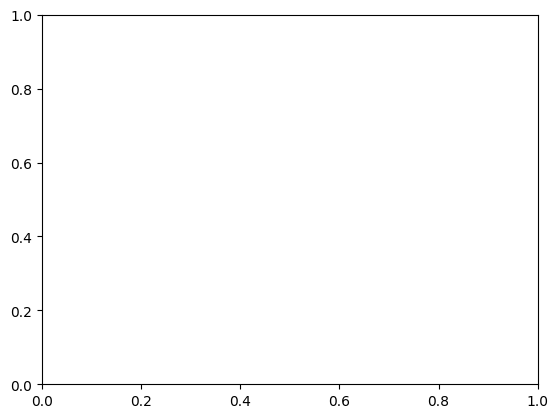

In [ ]:
# Test de correlation
plt.scatter(df["Concentration (ng/m3)"], meteo[meteo.date == df["Date"].iloc[0]].precipitation_sum)